# 01 — Adatmegértés és leakage-safe benchmark felépítése

Ebben a notebookban **nem modellezünk**. A cél az, hogy pontosan megértsük, milyen adaton fogjuk összehasonlítani a promptokat, és még az API-hívások előtt kizárjuk azokat a hibákat, amelyek hamis benchmark-eredményt adnának.

A gondolkodási sorrend:

**Üzleti probléma → adatséma → adatminőség → osztályeloszlás → szöveghossz → balanced mintavétel → development / holdout / few-shot szétválasztás → leakage ellenőrzés.**

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "02_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")

Project root: <PROJECT_ROOT>


## 1. Mi a valós üzleti probléma?

Egy SaaS vállalat support ticketjeit automatikusan a megfelelő csapathoz kell irányítani. A modell kimenete ezért nem szabad szöveg, hanem pontosan egy intent label:

`api / billing / cancellation / complaint / technical / upgrade`

### Miért jó ez Prompt Engineering benchmarknak?

Mert **objektív ground truth** áll rendelkezésre. Ha chatbot-válaszokat generálnánk, több különböző válasz is lehetne elfogadható, ezért szükség lenne emberi értékelésre vagy LLM-as-a-judge-ra. Itt viszont egyértelműen mérhető, hogy a predicted label megegyezik-e a true labellel.

**Döntés:** classification feladatot választunk, mert így a prompt engineering hatása közvetlenül számszerűsíthető.

## 2. Miért nyilvános, címkézett dataset?

A fő projekt a `cngchis/Support-Ticket-Router-12K-Cleaned` adathalmazra épül. Nyilvános adatforrás mellett egy recruiter vagy reviewer reprodukálni tudja a pipeline-t.

A repository tartalmaz egy kicsi lokális mintát is. Ez **nem végső benchmark**, csak arra szolgál, hogy API-kulcs nélkül ellenőrizhető legyen a teljes kód.

## 2/A. Mock adat és mock modell: két külön fogalom

A repository most 720 soros szintetikus datasetet is tartalmaz (`01_data/mock/mock_support_tickets.csv`). Ez azért kell, hogy internet nélkül is előállítható legyen a 300 soros benchmark és a 300 soros development split.

Fontos különbség:

- **mock data** = szintetikus input, amit akár valódi LLM is klasszifikálhat;
- **mock provider** = nem LLM, hanem determinisztikus keyword classifier.

A végső GitHub-eredményhez a legjobb kombináció: **public Hugging Face data + real LLM provider**.


In [2]:
import pandas as pd

mock_path = PROJECT_ROOT / "01_data/mock/mock_support_tickets.csv"
if mock_path.exists():
    mock_frame = pd.read_csv(mock_path)
    print("Included mock rows:", len(mock_frame))
    display(mock_frame.groupby("label").size().rename("rows").to_frame())


Included mock rows: 720


,rows
label,
api,120
billing,120
cancellation,120
complaint,120
technical,120
upgrade,120


In [3]:
import pandas as pd

processed_path = PROJECT_ROOT / "01_data/processed/benchmark.csv"
sample_path = PROJECT_ROOT / "01_data/sample/support_tickets_sample.csv"

if processed_path.exists():
    frame = pd.read_csv(processed_path).rename(columns={"true_label": "label"})
    source_name = "prepared benchmark.csv"
else:
    frame = pd.read_csv(sample_path)
    source_name = "local smoke-test sample"

print(f"Loaded source: {source_name}")
print(f"Rows: {len(frame):,}")
frame.head(10)

Loaded source: prepared benchmark.csv
Rows: 300


,sample_id,text,label,case_type,difficulty,secondary_label,scenario_id,scenario_notes
0,bench_0000,"Hi support, the application crashes whenever i...",technical,noisy_typo,medium,api,technical_noisy_typo_100,"Typos, casing and punctuation noise reduce lex..."
1,bench_0001,Could you help? My credit card payment for Bas...,upgrade,ambiguous_boundary,hard,billing,upgrade_ambiguous_boundary_058,Contains a strong billing cue before the actua...
2,bench_0002,"Hello, This service has been frustrating for w...",complaint,easy_clear,easy,technical,complaint_easy_clear_056,Single explicit intent with strong lexical cues.
3,bench_0003,"Hello. For context, last month we discussed on...",api,long_context,hard,billing,api_long_context_045,Long irrelevant context contains distractor in...
4,bench_0004,"Good morning, Where can I find the API documen...",technical,ambiguous_boundary,hard,api,technical_ambiguous_boundary_042,Contains a strong api cue before the actual te...
5,bench_0005,"Hello. For context, last month we discussed on...",technical,long_context,hard,complaint,technical_long_context_077,Long irrelevant context contains distractor in...
6,bench_0006,Could you help? The way this case has been han...,complaint,implicit_request,medium,billing,complaint_implicit_request_033,Primary intent is implied rather than stated w...
7,bench_0007,"Hello. For context, last month we discussed on...",cancellation,long_context,hard,complaint,cancellation_long_context_045,Long irrelevant context contains distractor in...
8,bench_0008,Our team noticed that the webhook signature fo...,api,noisy_typo,medium,technical,api_noisy_typo_084,"Typos, casing and punctuation noise reduce lex..."
9,bench_0009,Previous resolved issue: My invoice shows an u...,complaint,resolved_history,hard,billing,complaint_resolved_history_031,Historical resolved billing cue competes with ...


### Mit nézzünk meg először?

Mielőtt bármilyen promptot optimalizálnánk, ellenőrizni kell:

- megvannak-e a szükséges `text` és `label` mezők;
- vannak-e üres szövegek;
- vannak-e ismeretlen label-ek;
- vannak-e duplikátumok;
- mennyire kiegyensúlyozottak az osztályok;
- milyen hosszúak a ticketek.

Ha ezek közül valamelyik hibás, a későbbi F1-score félrevezető lehet.

In [4]:
required_columns = {"text", "label"}
missing_columns = required_columns - set(frame.columns)
print("Missing required columns:", missing_columns)
print("Null values:")
print(frame[["text", "label"]].isna().sum())
print("Blank texts:", int(frame["text"].astype(str).str.strip().eq("").sum()))

Missing required columns: set()
Null values:
text     0
label    0
dtype: int64
Blank texts: 0


## 3. Duplikátumok vizsgálata

A duplikált ticketek különösen problémásak, ha ugyanaz a szöveg bekerül a promptfejlesztési és a végső holdout készletbe. Ilyenkor az eredmény túl optimista lehet.

**Döntés:** tisztításkor a projekt exact `text + label` duplikátumokat eltávolít.

In [5]:
duplicate_count = int(frame.duplicated(subset=["text", "label"]).sum())
print(f"Exact text+label duplicates: {duplicate_count}")

Exact text+label duplicates: 0


## 4. Osztályeloszlás

A végső benchmarkot **balanced** módon építjük fel: minden osztályból ugyanannyi minta kerül bele.

### Miért?

A cél most nem egy konkrét vállalat természetes ticketforgalmának pontos utánzása, hanem a promptstratégiák kontrollált összehasonlítása. Ha például a `technical` kategória dominálna, az Accuracy főként ennek a kategóriának a teljesítményét tükrözné.

Balanced holdout esetén minden intent egyforma súlyt kap.

label
api             50
billing         50
cancellation    50
complaint       50
technical       50
upgrade         50
Name: count, dtype: int64


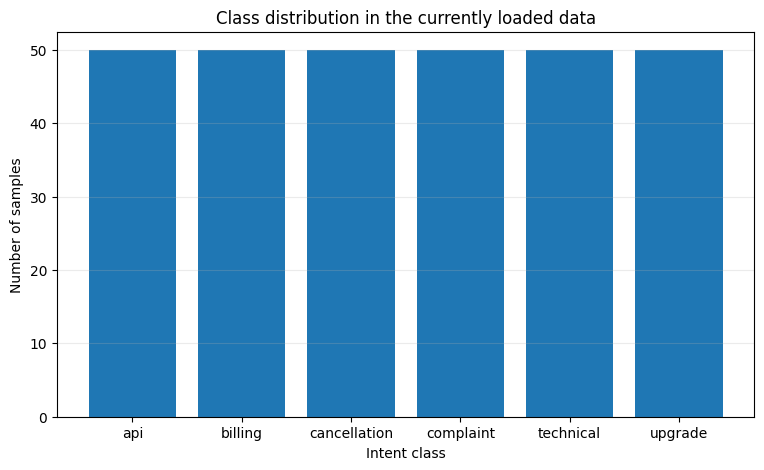

In [6]:
import matplotlib.pyplot as plt

class_counts = frame["label"].value_counts().sort_index()
print(class_counts)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(class_counts.index, class_counts.values)
ax.set_title("Class distribution in the currently loaded data")
ax.set_xlabel("Intent class")
ax.set_ylabel("Number of samples")
ax.grid(axis="y", alpha=0.25)
plt.show()

### Mit jelent az ábra?

Ha a forrásadat nem balanced, az önmagában nem probléma. A lényeg az, hogy a **végső összehasonlító benchmark** legyen kontrollált. Production monitoring esetén természetesen a természetes forgalmi eloszlást is külön vizsgálnánk.

## 5. Szöveghossz vizsgálata

A ticket hossza LLM-költséget és esetenként classification nehézséget is befolyásol. Ezért nem elég csak a label-eket megnézni.

In [7]:
analysis = frame.copy()
analysis["word_count"] = analysis["text"].astype(str).str.split().str.len()
analysis["character_count"] = analysis["text"].astype(str).str.len()
analysis[["word_count", "character_count"]].describe().round(2)

,word_count,character_count
count,300.00,300.00
mean,38.95,239.24
std,17.01,103.53
min,11.00,78.00
25%,18.75,115.75
50%,47.50,275.50
75%,52.00,312.00
max,64.00,402.00


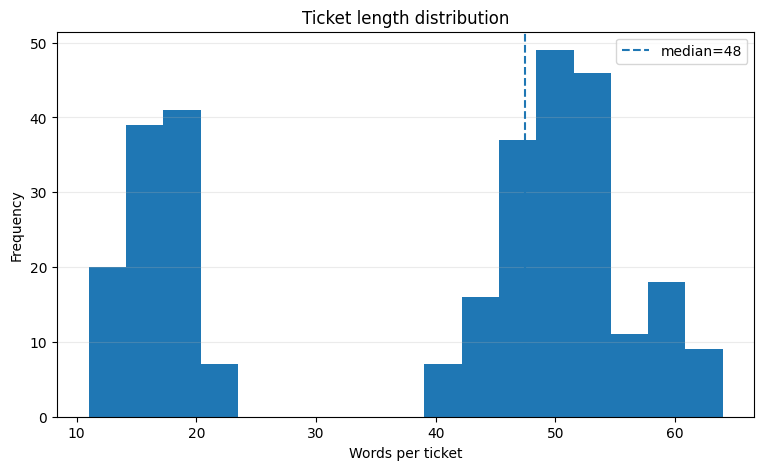

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(analysis["word_count"], bins=max(5, min(25, int(len(analysis) ** 0.5))))
ax.axvline(analysis["word_count"].median(), linestyle="--", label=f"median={analysis['word_count'].median():.0f}")
ax.set_title("Ticket length distribution")
ax.set_xlabel("Words per ticket")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.show()

### Miért fontos ezt dokumentálni?

Két prompt azonos ticketeken fut. Így a bemeneti szöveg hosszából eredő tokenigény mindkettőnél ugyanaz; a különbség főként a prompt overheadből származik. Ez segít korrektül értelmezni a few-shot és hosszabb policy promptok többletköltségét.

## 6. A három adatkomponens

A projekt három **diszjunkt** részhalmazt hoz létre:

1. **Few-shot examples** — kizárólag a promptban mutatott példák.
2. **Development set** — promptfejlesztéshez és ablation studyhoz.
3. **Final holdout benchmark** — egyszeri végső összehasonlításhoz.

Ez a struktúra ML-szemléletű: a development adaton fejlesztünk, a holdoutot pedig nem használjuk iteratív tuningra.

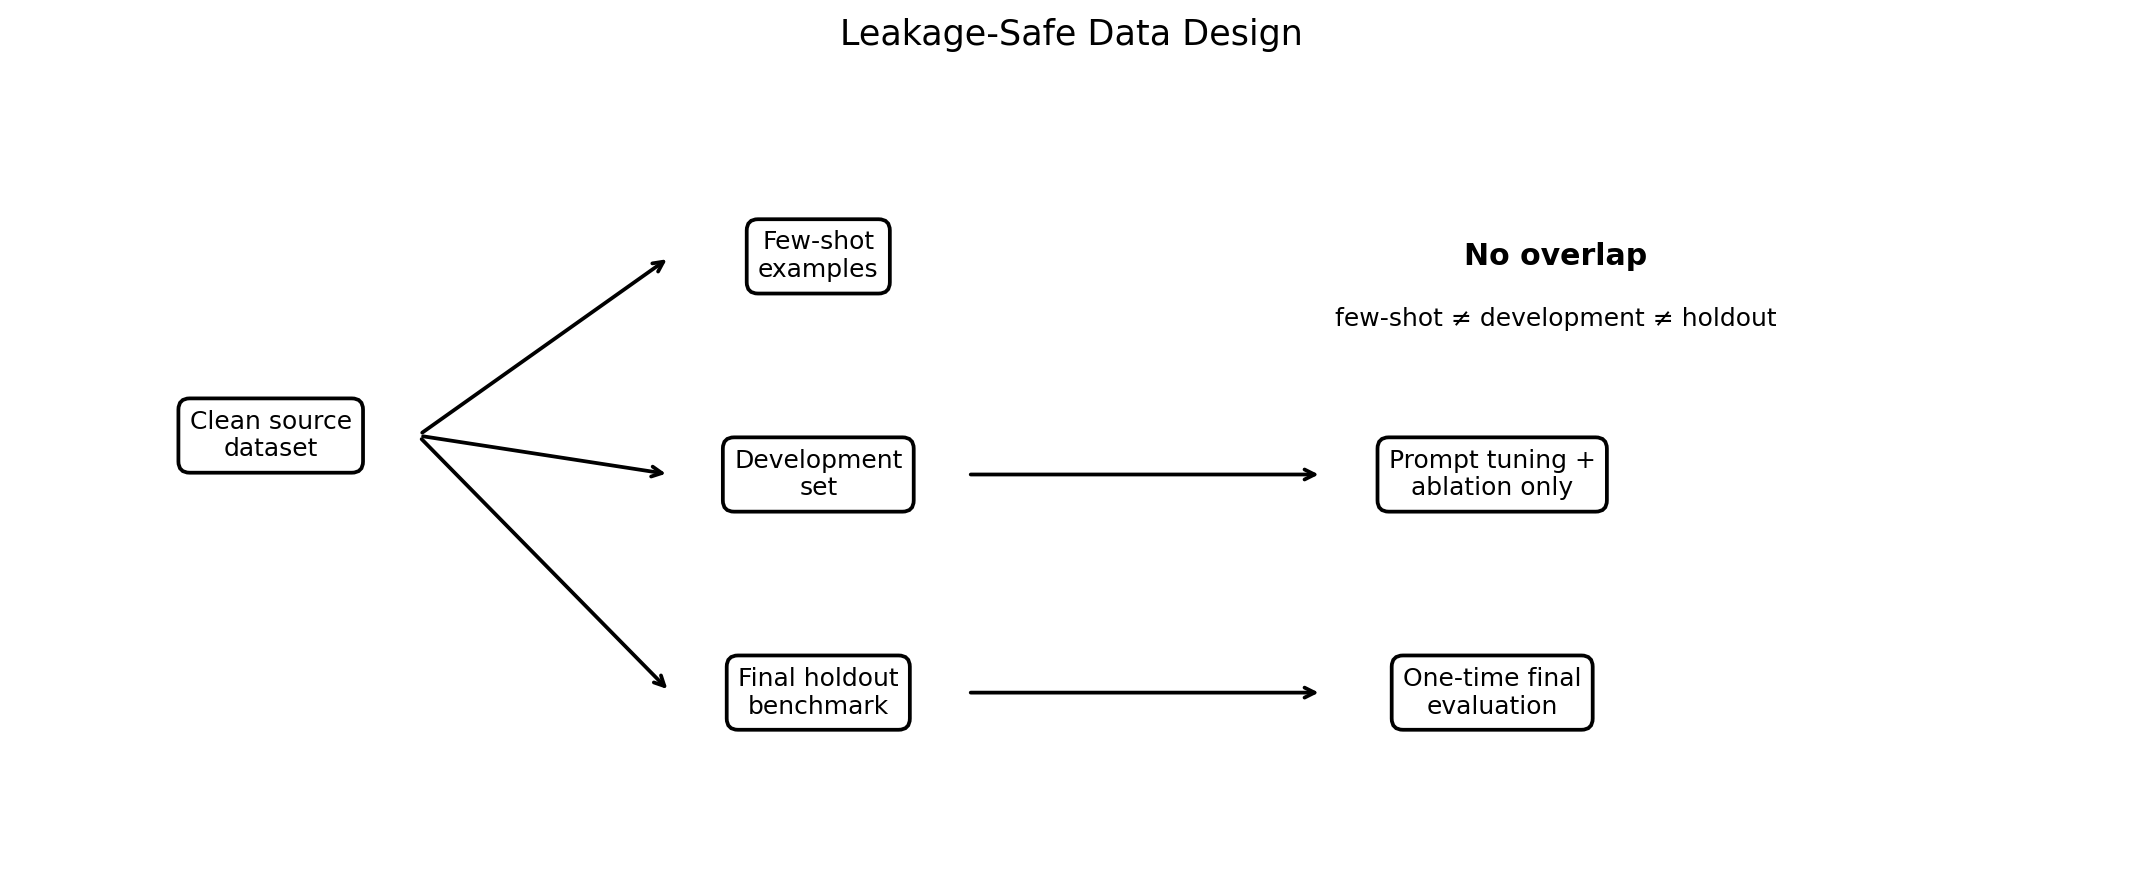

In [9]:
from IPython.display import Image, display

diagram = PROJECT_ROOT / "07_outputs/reports/figures/00b_leakage_safe_split.png"
if diagram.exists():
    display(Image(filename=str(diagram)))
else:
    print("Generate the conceptual diagrams with: python 05_scripts/08_generate_diagrams.py")

## 7. Mi az a prompt overfitting?

Ha a final benchmark hibáit újra és újra megnézzük, majd ezek alapján módosítjuk a promptot, akkor a prompt fokozatosan **a teszthalmazhoz idomul**. Ettől a végső F1 nőhet, de az általánosíthatóság nem feltétlenül.

**Ezért a döntés:**

- prompt iteration → development set;
- ablation → development set;
- final score → frozen holdout;
- holdout után nincs új prompttuning ugyanarra a benchmarkra.

## 8. A split létrehozása

A valódi dataset esetén a projekt alapértelmezése:

- 50 minta / class final benchmark → 300 minta;
- 50 minta / class development → 300 minta;
- 2 few-shot példa / class → 12 példa;
- random seed = 42.

A 300-as méret kompromisszum: már ad értelmes per-class mérési alapot, de nyolc promptstratégia mellett még kezelhető API-költségű.

In [10]:
print("Real-data command:")
print("python 05_scripts/02_prepare_data.py --source huggingface")
print()
print("Offline smoke-test command:")
print("python 05_scripts/02_prepare_data.py --source sample --benchmark-per-class 2 --development-per-class 2 --few-shot-per-class 1")

Real-data command:
python 05_scripts/02_prepare_data.py --source huggingface

Offline smoke-test command:
python 05_scripts/02_prepare_data.py --source sample --benchmark-per-class 2 --development-per-class 2 --few-shot-per-class 1


## 9. Leakage ellenőrzése programból

Nem elég azt mondani, hogy nincs overlap — ellenőrizni is kell.

In [11]:
benchmark_path = PROJECT_ROOT / "01_data/processed/benchmark.csv"
development_path = PROJECT_ROOT / "01_data/processed/development.csv"
few_shot_path = PROJECT_ROOT / "configs/prompts/examples/few_shot_examples.json"

if benchmark_path.exists() and development_path.exists() and few_shot_path.exists():
    import json
    benchmark = pd.read_csv(benchmark_path)
    development = pd.read_csv(development_path)
    few_shot = pd.DataFrame(json.loads(few_shot_path.read_text(encoding="utf-8")))

    benchmark_dev_overlap = set(benchmark["text"]) & set(development["text"])
    benchmark_few_overlap = set(benchmark["text"]) & set(few_shot["text"])
    dev_few_overlap = set(development["text"]) & set(few_shot["text"])

    print("benchmark ↔ development overlap:", len(benchmark_dev_overlap))
    print("benchmark ↔ few-shot overlap:", len(benchmark_few_overlap))
    print("development ↔ few-shot overlap:", len(dev_few_overlap))
else:
    print("Prepared files not found yet. Run 05_scripts/02_prepare_data.py first.")

benchmark ↔ development overlap: 0
benchmark ↔ few-shot overlap: 0
development ↔ few-shot overlap: 0


## 10. Mit viszünk tovább a következő notebookba?

A promptbenchmark csak akkor értelmezhető, ha az adatoldalt már lezártuk. Innentől a final holdout változatlan. A következő notebookban azt bontjuk szét, **milyen promptkomponenseket változtatunk és mi a hipotézisünk mindegyik mögött**.

A részletes döntési napló: `docs/ENGINEERING_DECISIONS.md`.